In [1]:
# Problem 1_2 
# SCIP implementation 
# Circle problem - minimze single objective x2, feasible region constrained by circle of radius 5, at 5,5 and 13,5
# Minimizing the number of steps
# Common Constraints Block
import pyomo.environ as pyo
import os
import cloudpickle as cp

# Default constraints using pyomo
def non_worsening_f1_rule(model, i, N_max, M, epsilon):
    if i == N_max:
        return pyo.Constraint.Skip
    return model.f1[i + 1] <= model.f1[i] + M*(2 - model.y[i] - model.y[i+1]) - epsilon

# Sequential Steps
def sequential_steps_rule(model, i, N_max):
    if i == N_max:
        return pyo.Constraint.Skip
    return model.y[i] >= model.y[i + 1]

def x_fixed_when_y_zero_lower_rule(model, i, j, x_lower, epsilon):
    return model.x[i, j] >= x_lower[j] * model.y[i] + (x_lower[j] + epsilon) * (1 - model.y[i])

def x_fixed_when_y_zero_upper_rule(model, i, j, x_lower, x_upper, epsilon):
    return model.x[i, j] <= x_upper[j] * model.y[i] + (x_lower[j] + epsilon) * (1 - model.y[i])

# Distance Constraints
def distance_constraint_rule(model, i, j, delta, M):
    if i == 0:
        return pyo.Constraint.Skip
    return abs(model.x[i, j] - model.x[i - 1, j]) <= delta[j] + M * (2 - model.y[i] - model.y[i - 1])

# Define z[i] to identify the last active step
def z_definition_rule1(model, i, N_max):
    if i == N_max:
        return pyo.Constraint.Skip
    return model.z[i] <= model.y[i]

def z_definition_rule2(model, i, N_max):
    if i == N_max:
        return pyo.Constraint.Skip
    return model.z[i] <= 1 - model.y[i + 1]

def z_definition_rule3(model, i, N_max):
    if i == N_max:
        return pyo.Constraint.Skip
    return model.z[i] >= model.y[i] - model.y[i + 1]

# Ensure end point is at the last active step
def end_point_constraint(model, i, j, N_max, M, x_end):
    if i == N_max:
        return pyo.Constraint.Skip
    return model.x[i, j] - x_end[j] <= M * (1 - model.z[i])

def end_point_constraint2(model, i, j, N_max, M, x_end):
    if i == N_max:
        return pyo.Constraint.Skip
    return x_end[j] - model.x[i, j] <= M * (1 - model.z[i])

# Normalizing f1
def normalize_f1(model, i, ideal_f1, nadir_f1):
    return (model.f1[i] - ideal_f1) / (nadir_f1 - ideal_f1)  # Added small epsilon to avoid division by zero
# Objective Function: Minimize the sum of x2 values

def objective_rule(model):
    return (
        sum(
            (model.f1_norm[i] + 1)*model.y[i]  # Example: Squared x2 squared, adjust as needed
            for i in model.steps
        )
    )

#import pyomo.environ as pyo
import numpy as np

# Problem data (updated)
n = 2  # Number of variables (x1 and x2)
N_max_actual = 20  # Number of steps (updated)
x_start = [9, 13]  # Starting point (x1, x2) (updated)
x_end = [9, 3]  # Ending point (x1, x2) (updated)
x_lower = [0.5, 0.5]  # Lower bounds for x1 and x2 (updated)
x_upper = [20.0, 20.0]  # Upper bounds for x1 and x2 (updated)
delta = [0.1*(x_upper[j] - x_lower[j]) for j in range(n)]  # Maximum distance between consecutive points (
M = 1e6  # Big-M constant
epsilon = 1e-4

N_max = N_max_actual + 1  # Maximum number of steps (updated)

# Infeasible regions defined by circles
circles = [
    {'center': (5, 8), 'radius': 5},    # Circle 1
    {'center': (13, 8), 'radius': 5}    # Circle 2
]

def compute_f1(x):
    return x[1]

# Compute f1 and f2 at x_start and x_end
f1_start = compute_f1(x_start)
f1_end = compute_f1(x_end)

# Determine ideal and nadir points
ideal_f1 = min(f1_start, f1_end)
nadir_f1 = max(f1_start, f1_end)

# Create Pyomo model
model = pyo.ConcreteModel()

# Sets
model.steps = pyo.RangeSet(0, N_max)
model.dimensions = pyo.RangeSet(0, n-1)  # 1 and 2 for x1 and x2
model.circles = pyo.RangeSet(1, len(circles))  # Circles

# Variables
model.x = pyo.Var(model.steps, model.dimensions, within=pyo.Reals,
                  bounds=lambda model, i, j: (x_lower[j], x_upper[j]))
model.y = pyo.Var(model.steps, within=pyo.Binary)
model.z = pyo.Var(model.steps, within=pyo.Binary)  # Auxiliary variable for end point

def compute_f1_expr(model, i):
    x2 = model.x[i, 1]
    return x2

model.f1 = pyo.Expression(model.steps, rule=compute_f1_expr)

# Normalizded f1
model.f1_norm = pyo.Expression(model.steps, rule=lambda model, i: normalize_f1(model, i, ideal_f1, nadir_f1))

# Objective
model.objective = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

# Constraints
model.non_worsening_f1 = pyo.Constraint(
    model.steps, 
    rule=lambda model, i: non_worsening_f1_rule(model, i, N_max, M, epsilon)
)

# Circle Exclusion Constraints (Ensure point is not inside any circle)
for i in model.steps:
    for c_idx, circle in enumerate(circles, start=1):
        h, k = circle['center']
        r = circle['radius']
        # Constraint: (x[i,1] - h)^2 + (x[i,2] - k)^2 >= r^2 - M*(1 - y[i])
        # When y[i] == 1 (active), enforce the constraint
        # When y[i] == 0 (inactive), constraint is relaxed due to big-M term
        lhs = (model.x[i, 0] - h) ** 2 + (model.x[i, 1] - k) ** 2
        rhs = r ** 2 - M * (1 - model.y[i])
        model.add_component(f'circle_exclusion_c{c_idx}_i{i}',
                            pyo.Constraint(expr=lhs >= rhs))

# Constraints
# Start Point Fixed
for j in model.dimensions:
    model.x[0, j].fix(x_start[j])
model.y[0].fix(1)  # Start step is active


# Sequential Steps
model.sequential_steps = pyo.Constraint(model.steps, rule= lambda model, i: sequential_steps_rule(model, i, N_max))

# Enforce x[i, j] = x_lower[j] + epsilon when y[i] = 0
model.x_fixed_when_y_zero_lower = pyo.Constraint(model.steps, model.dimensions, rule= lambda model, i, j: x_fixed_when_y_zero_lower_rule(model, i, j, x_lower, epsilon))
model.x_fixed_when_y_zero_upper = pyo.Constraint(model.steps, model.dimensions, rule= lambda model, i, j: x_fixed_when_y_zero_upper_rule(model, i, j, x_lower, x_upper, epsilon))

# Distance Constraint
model.distance_constraints = pyo.Constraint(model.steps, model.dimensions, rule= lambda model, i, j: distance_constraint_rule(model, i, j, delta, M))

# Active Step Identification
model.z_definition1 = pyo.Constraint(model.steps, rule= lambda model, i: z_definition_rule1(model, i, N_max))
model.z_definition2 = pyo.Constraint(model.steps, rule= lambda model, i: z_definition_rule2(model, i, N_max))
model.z_definition3 = pyo.Constraint(model.steps, rule= lambda model, i: z_definition_rule3(model, i, N_max))
# At lease one step has to be active.
model.sum_z = pyo.Constraint(expr=sum(model.z[i] for i in model.steps if i < N_max) == 1)

# Ensure end point is at the last active step
model.end_point_constraint1 = pyo.Constraint(model.steps, model.dimensions, rule= lambda model, i, j: end_point_constraint(model, i, j, N_max, M, x_end))
model.end_point_constraint2 = pyo.Constraint(model.steps, model.dimensions, rule= lambda model, i, j: end_point_constraint2(model, i, j, N_max, M, x_end))

# Solver Configuration: Using SCIP
solver = pyo.SolverFactory('scip')

# Optional: Set SCIP-specific solver options
solver.options['limits/time'] = 20*60  # Time limit in seconds
#solver.options['limits/gap'] = 0.01    # Break condition when gap < 1%
solver.options['presolving/maxrounds'] = 5  # Presolving rounds

# Solve the model
result = solver.solve(model, tee=True)

# Check Solver Status
if (result.solver.status == pyo.SolverStatus.ok) and \
   (result.solver.termination_condition in [pyo.TerminationCondition.optimal, pyo.TerminationCondition.feasible]):
    print("\nSolution is feasible")
elif result.solver.termination_condition == pyo.TerminationCondition.infeasible:
    print("\nNo solution found")
else:
    print("\nSolver Status:", result.solver.status)

if result.solver.status == "warning" and result.solver.termination_condition == "infeasible":
    pass
else:
    # Extract and Display the Solution
    x_solution = []
    for i in model.steps:
        y_i_value = pyo.value(model.y[i])
        if y_i_value > 0.5:
            x_i = np.array([pyo.value(model.x[i, j]) for j in model.dimensions])
            x_solution.append(x_i)

    print("\nOptimal sequence of points:")
    for idx, x_i in enumerate(x_solution):
        print(f"Step {idx}: x = {x_i}")

    # Compute and Print Objective Function Value

    objective_value = pyo.value(model.objective)
    print(f"\nObjective Function Value: {objective_value:.6f}")

    sum_fi = 0

    # Verify Circle Exclusion Constraints
    print("\nVerification of Circle Exclusion Constraints:")
    active_steps = [i for i in model.steps if pyo.value(model.y[i]) > 0.5]
    i_step = 0
    for i in active_steps:
        i_step = i_step + 1
        x_i = [pyo.value(model.x[i, j]) for j in model.dimensions]
        x1, x2 = x_i

        fi = x2
        sum_fi = sum_fi + fi

        print(f"\nStep {i_step}:")
        print(f"  x = {x_i}")
        print(f"  f(x) = {fi:.6f}")

        inside_any_circle = False
        for c_idx, circle in enumerate(circles, start=1):
            h, k = circle['center']
            r = circle['radius']
            lhs = (x1 - h) ** 2 + (x2 - k) ** 2
            if lhs < r **2:
                inside_any_circle = True
                break
        status = "Outside" if not inside_any_circle else "Inside"
        print(f"  Step {i_step}: Point ({x1:.6f}, {x2:.6f}) is {status} the circles --> {'Satisfied' if not inside_any_circle else 'Violated'}")

    print(f"\nSum of  f: {sum_fi:.6f}")

    # Verify Distance Constraints Between Consecutive Active Steps
    print("\nVerification of Distance Constraints Between Consecutive Active Steps:")
    active_steps = [i for i in model.steps if pyo.value(model.y[i]) > 0.5]
    for idx in range(1, len(active_steps)):
        i_prev = active_steps[idx - 1]
        i_curr = active_steps[idx]
        distance = []
        for j in range(n):
            distance.append(pyo.sqrt((pyo.value(model.x[i_curr, j]) - pyo.value(model.x[i_prev, j]))**2))
        distance_status = "Satisfied" if all(distance[j] <= delta[j] for j in range(n)) else "Violated"
        print(f"Distance between Step {i_prev} and Step {i_curr}:")
        for j in range(n):
            dim_status = "Satisfied" if distance[j] <= delta[j] else "Violated"
            print(f"  Dimension {j}: Distance = {distance[j]:.6f} (delta = {delta[j]}) --> {dim_status}")
        print(f"Overall Status: {distance_status}\n")    

    # Verifying epsilon constraints for circle problem 

    # Verify Circle Exclusion Constraints
    print("\nVerification of epsilon Circle Exclusion Constraints:")
    active_steps = [i for i in model.steps if pyo.value(model.y[i]) > 0.5]
    i_step = 0
    for i in active_steps:
        i_step = i_step + 1
        x_i = [pyo.value(model.x[i, j]) for j in model.dimensions]
        x1, x2 = x_i
        fi = x2**2
        print(f"\nStep {i_step}:")
        print(f"  x = {x_i}")
        print(f"  f(x) = {fi:.6f}")

        inside_any_circle = False
        for c_idx, circle in enumerate(circles, start=1):
            h, k = circle['center']
            r = circle['radius']
            lhs = (x1 - h) ** 2 + (x2 - k) ** 2
            lhs_sqt = np.sqrt(lhs)
            if lhs_sqt < r - epsilon:
                inside_any_circle = True
                break
        status = "Outside" if not inside_any_circle else "Inside"
        print(f"  Step {i_step}: Point ({x1:.6f}, {x2:.6f}) is {status} the circles --> {'Epsilon Satisfied' if not inside_any_circle else 'Violated'}")

    print(f"\nSum of fs: {sum_fi:.6f}")


    # --- after solver.solve(model) and status‐checking ---

    # After solving and status‐checking…
    results_dir = os.path.join(os.getcwd(), "results", "circle_problem")
    os.makedirs(results_dir, exist_ok=True)
    model_path = os.path.join(results_dir, "circle_model.pkl")

    # Save the entire Pyomo model with cloudpickle
    with open(model_path, "wb") as f:
        cp.dump(model, f)
    print(f"✔ Solved model (with lambdas) saved to {model_path}")

SCIP version 9.2.2 [precision: 8 byte] [memory: block] [mode: optimized] [LP solver: SoPlex 7.1.4] [GitHash: 416226a4f8]
Copyright (c) 2002-2025 Zuse Institute Berlin (ZIB)

External libraries: 
  SoPlex 7.1.4         Linear programming solver developed at Zuse Institute Berlin (soplex.zib.de) [GitHash: 7c53d552]
  CppAD 20180000.0     Algorithmic Differentiation of C++ algorithms developed by B. Bell (github.com/coin-or/CppAD)
  ZLIB 1.3.1           General purpose compression library by J. Gailly and M. Adler (zlib.net)
  GMP 6.3.0            GNU Multiple Precision Arithmetic Library developed by T. Granlund (gmplib.org)
  ZIMPL 3.6.2          Zuse Institute Mathematical Programming Language developed by T. Koch (zimpl.zib.de)
  AMPL/MP 690e9e7      AMPL .nl file reader library (github.com/ampl/mp)
  PaPILO 2.4.2         parallel presolve for integer and linear optimization (github.com/scipopt/papilo) (built with TBB) [GitHash: 4b399c4c]
  Nauty 2.8.8          Computing Graph Automor

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


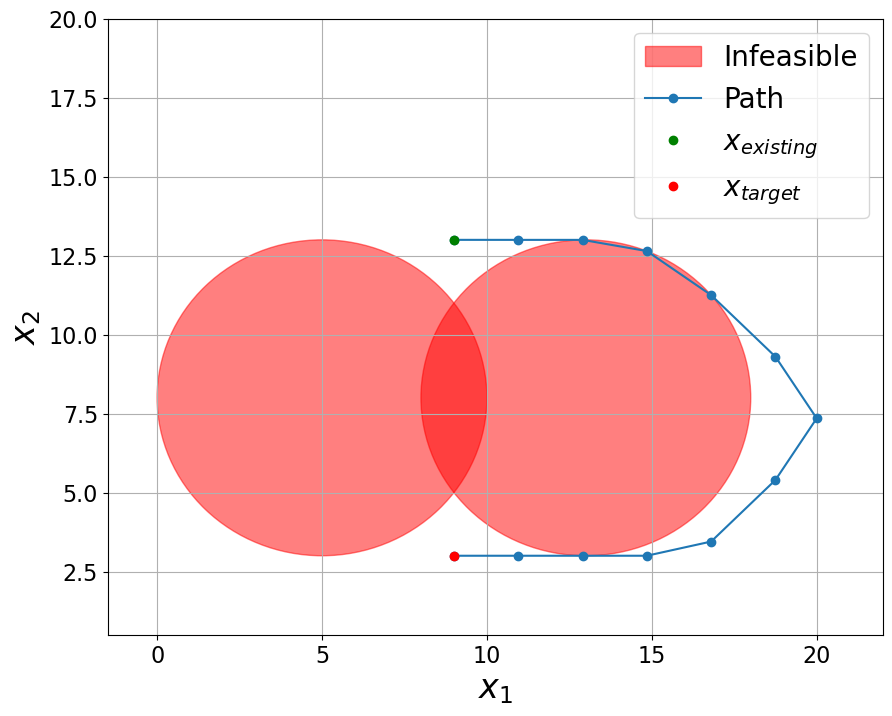

In [9]:
import os
import cloudpickle as cp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import pyomo.environ as pyo


x_start = [9, 13]  # Starting point (x1, x2) (updated)
x_end = [9, 3]  # Ending point (x1, x2) (updated)
x_lower = [0.5, 0.5]  # Lower bounds for x1 and x2 (updated)
x_upper = [20.0, 20.0]  # Upper bounds for x1 and x2 (updated)


# Infeasible regions defined by circles
circles = [
    {'center': (5, 8), 'radius': 5},    # Circle 1
    {'center': (13, 8), 'radius': 5}    # Circle 2
]
results_dir = os.path.join(os.getcwd(), "results", "circle_problem")
model_path  = os.path.join(results_dir, "circle_model.pkl")

# Reload the full model
with open(model_path, "rb") as f:
    loaded_model = cp.load(f)

# Extract just as before
x_solution = []
for i in loaded_model.steps:
    if pyo.value(loaded_model.y[i]) > 0.5:
        x_i = np.array([pyo.value(loaded_model.x[i, j]) 
                        for j in loaded_model.dimensions])
        x_solution.append(x_i)

# Plotting…
fig, ax = plt.subplots(figsize=(10, 8))
for circle in circles:
    h, k = circle["center"]
    r     = circle["radius"]
    ax.add_patch(Circle((h, k), r, alpha=0.5, color="red", label="Infeasible"))

if x_solution:
    path = np.array(x_solution)
    ax.plot(path[:,0], path[:,1], marker="o", linestyle="-", label="Path")

ax.plot(x_start[0], x_start[1], "go", label="$x_{existing}$")
ax.plot(x_end[0],   x_end[1],   "ro", label="$x_{target}$")

#ax.set_title("Optimal Path Avoiding Infeasible Regions")
ax.set_xlabel("$x_1$", fontsize=24)
ax.set_ylabel("$x_2$", fontsize=24)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_xlim(x_lower[0]-2, x_upper[0]+2)
ax.set_ylim(x_lower[1], x_upper[1])
ax.grid(True)
handles, labels = ax.get_legend_handles_labels()
uniq = [(h,l) for i,(h,l) in enumerate(zip(handles,labels)) if l not in labels[:i]]
ax.legend(*zip(*uniq), fontsize=20, loc='upper right')

# Save as PNG & EPS
figures_dir = os.path.join(results_dir, "figures")
os.makedirs(figures_dir, exist_ok=True)
fig.savefig(os.path.join(figures_dir, "circle_path.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(figures_dir, "circle_path.eps"), format="eps", bbox_inches="tight")
plt.show()
